In [33]:
import sys
#sys.path.insert(1, '/home/santolam/MyPythonLibrary/MAR-RECAP/libmar/')
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
#sys.path.insert(1, '/Users/santolam/Documents/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

In [3]:
iyr=1980;fyr=2024
domain='GRf'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [4]:
# Jasgulem ice core coordinates:
jasg_lat = 38.54063
jasg_lon = 72.269816

In [7]:
season_list = ["DJF", "MAM", "JJA", "SON"]

In [8]:
domain_2 = 'GRp'

In [9]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
# sourceData_3='/bettik/PROJECTS/pr-regional-climate/santolam/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [10]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [12]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve la carotte Jasgulem

# distance sur grille
dist = np.sqrt((ds_lat - jasg_lat)**2 + (ds_lon - jasg_lon)**2)

# index 1D du minimum
idx_1d = dist.argmin().item()

# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude trouvée :", ds_lat[iY, iX].item())
print("Longitude trouvée :", ds_lon[iY, iX].item())

Indice Y : 26
Indice X : 47
Latitude trouvée : 38.54820251464844
Longitude trouvée : 72.30000305175781


/tmp/ipykernel_956750/3964833802.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


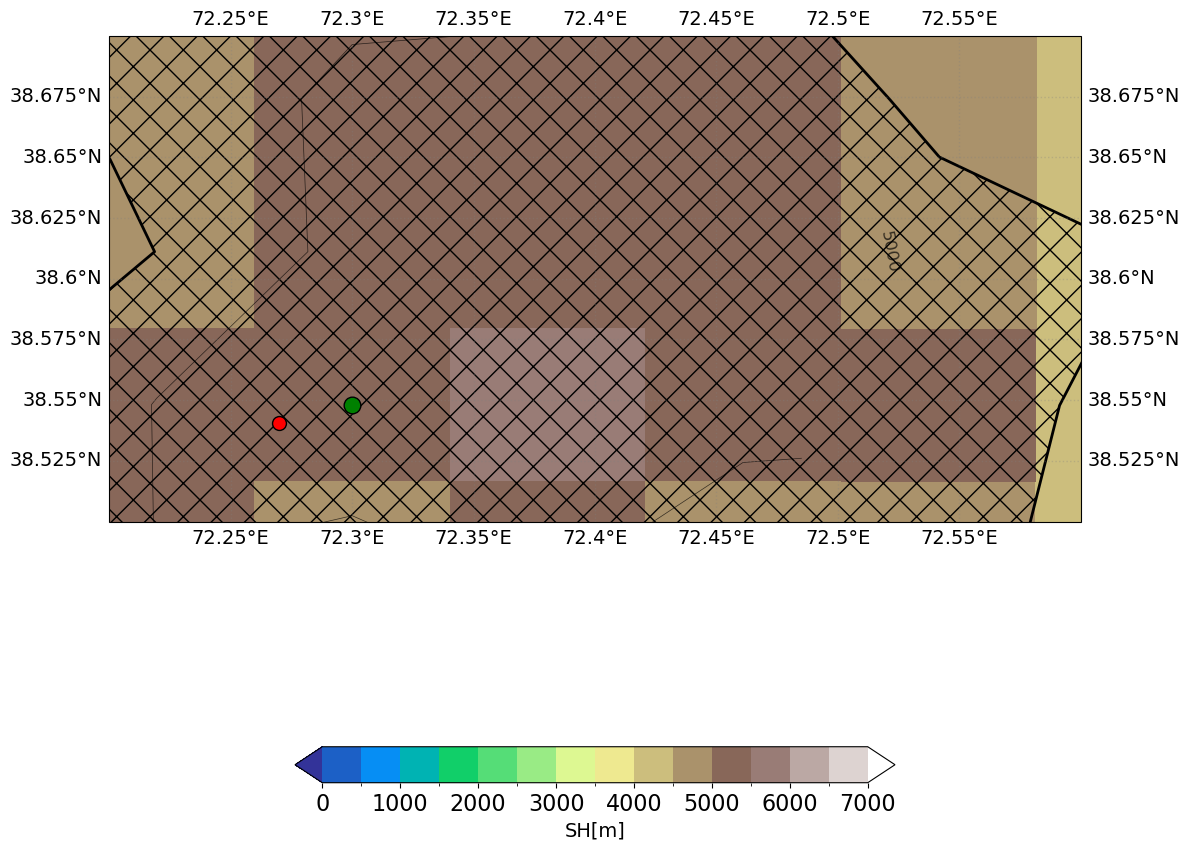

In [14]:
ice_level=32# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
ax.set_extent([72.2, 72.6, 38.5, 38.7], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Jasgulem ice core : red dot
ax.plot(jasg_lon, jasg_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

# Identifier le point de grille ou se trouve la carotte Jasgulem
ax.plot(ds_lon[iY, iX], ds_lat[iY, iX],
        marker='o', markersize=12,
        markeredgecolor='black', markerfacecolor='green',
        transform=ccrs.PlateCarree())

plt.show()

/tmp/ipykernel_956750/2380923148.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


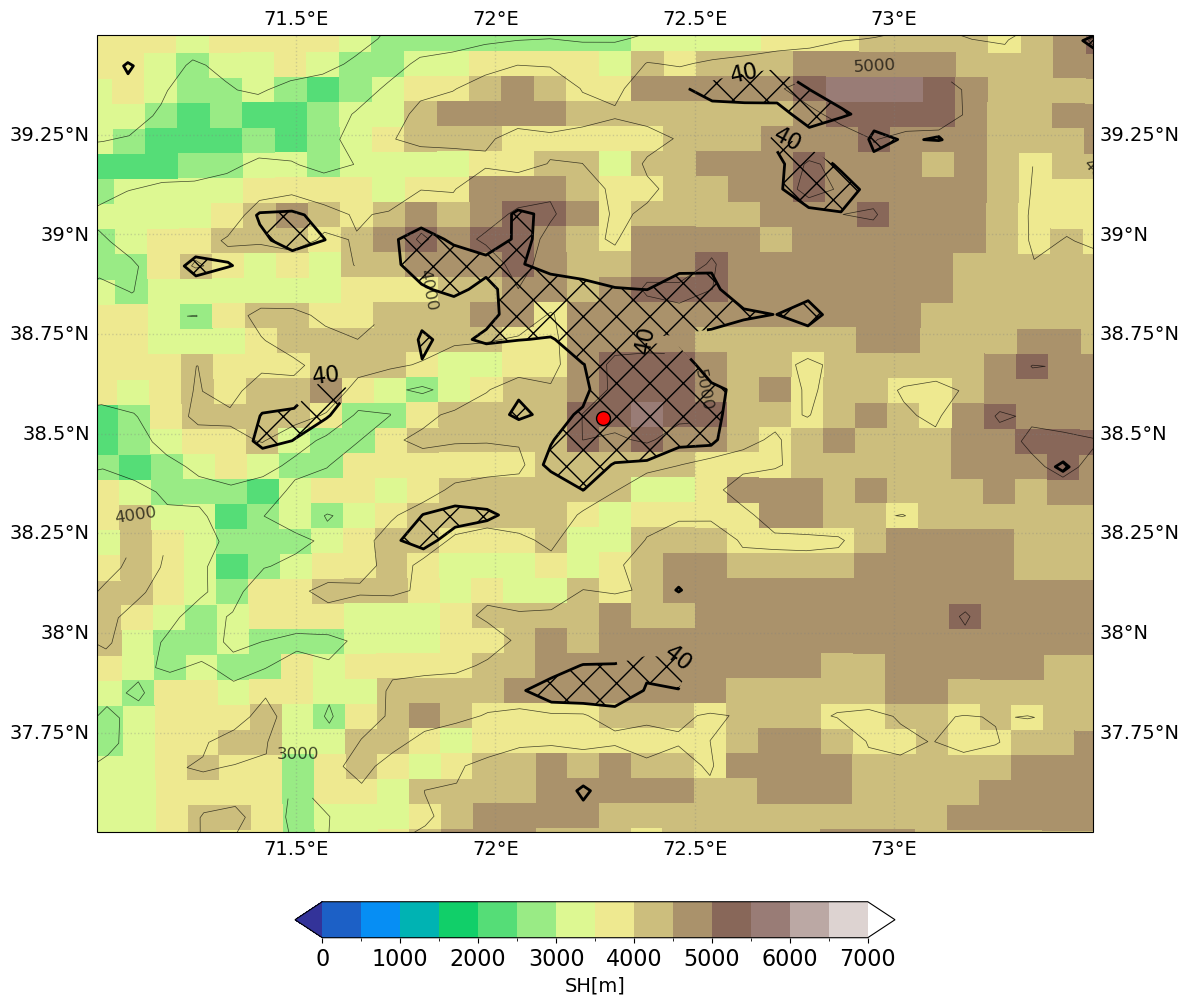

In [15]:
ice_level=40# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
ax.set_extent([71, 73.5, 37.5, 39.5], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Jasgulem ice core : red dot
ax.plot(jasg_lon, jasg_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

plt.show()

In [16]:
variable='TTZ' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds_TTZ= xr.open_dataset(sourceData_1+fileNameF).isel(ZTQLEV=0).TTZ.load()

ds_TTZ = ds_TTZ.assign_coords(X=np.round(ds_TTZ.X.values))
ds_TTZ = ds_TTZ.assign_coords(Y=np.round(ds_TTZ.Y.values))
ds_TTZ = ds_TTZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_TTZ = ds_TTZ[:,k:-k,k:-k]

In [17]:
variable='RF'

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds_RF= xr.open_dataset(sourceData_1+fileNameF).RF.load()

ds_RF = ds_RF.assign_coords(X=np.round(ds_RF.X.values))
ds_RF = ds_RF.assign_coords(Y=np.round(ds_RF.Y.values))
ds_RF = ds_RF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RF = ds_RF[:,k:-k,k:-k]

In [18]:
variable='SF'

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds_SF= xr.open_dataset(sourceData_1+fileNameF).SF.load()

ds_SF = ds_SF.assign_coords(X=np.round(ds_SF.X.values))
ds_SF = ds_SF.assign_coords(Y=np.round(ds_SF.Y.values))
ds_SF = ds_SF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SF = ds_SF[:,k:-k,k:-k]

In [19]:
variable='ME' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds_ME= xr.open_dataset(sourceData_1+fileNameF).ME.isel(SECTOR1_1=0).load()

ds_ME = ds_ME.assign_coords(X=np.round(ds_ME.X.values))
ds_ME = ds_ME.assign_coords(Y=np.round(ds_ME.Y.values))
ds_ME = ds_ME.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_ME = ds_ME[:,k:-k,k:-k]

In [20]:
variable='SMB' 
#"Surface Mass Balance (SMB~SF+RF-RU-SU-SW)" 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_1980-2024.nc'
ds_SMB= xr.open_dataset(sourceData_1+fileNameF).SMB.isel(SECTOR=0).load()

ds_SMB = ds_SMB.assign_coords(X=np.round(ds_SMB.X.values))
ds_SMB = ds_SMB.assign_coords(Y=np.round(ds_SMB.Y.values))
ds_SMB = ds_SMB.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMB = ds_SMB[:,k:-k,k:-k]

In [21]:
##Fedchenko Accumulation basin

mask_Fed = (
    (ds_lon >= 72.25) & (ds_lon <= 72.5) &
    (ds_lat >= 38.5) & (ds_lat <= 38.7)
)

SH_Fed = ds_SH.where(mask_Fed, drop=True)
lon_Fed = ds_lon.where(mask_Fed, drop=True)
lat_Fed = ds_lat.where(mask_Fed, drop=True)

ds_TTZ_Fed = ds_TTZ.where(mask_Fed, drop=True)
ds_RF_Fed = ds_RF.where(mask_Fed, drop=True)
ds_SF_Fed = ds_SF.where(mask_Fed, drop=True)
ds_ME_Fed = ds_ME.where(mask_Fed, drop=True)
ds_SMB_Fed = ds_SMB.where(mask_Fed, drop=True)

/tmp/ipykernel_956750/229444792.py:11: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(ds_lon_jasg, ds_lat_jasg, ds_SH_jasg, shading='auto')#,vmin=0, vmax=100)


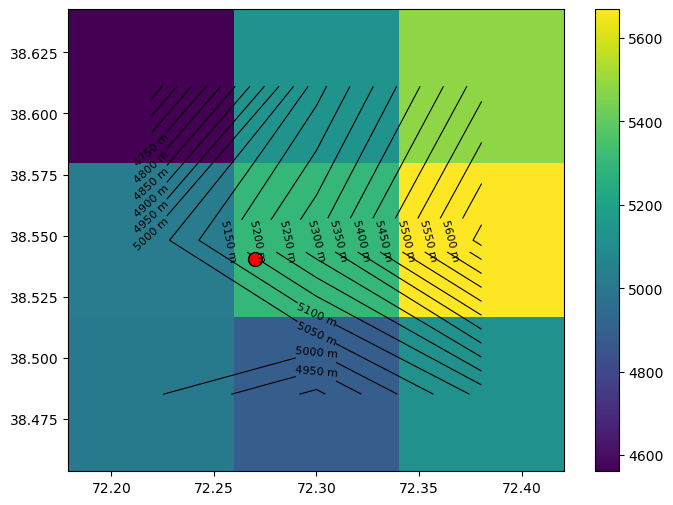

In [22]:
ds_SH_jasg = ds_SH.isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2))
ds_lat_jasg = ds_lat.isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2))
ds_lon_jasg = ds_lon.isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2))

X, Y = np.meshgrid([0,1,2], [0,1,2])

levels = np.arange(3000, 6500, 50)  

fig, ax = plt.subplots(figsize=(8,6))

m = ax.pcolormesh(ds_lon_jasg, ds_lat_jasg, ds_SH_jasg, shading='auto')#,vmin=0, vmax=100)                   
contours = ax.contour(ds_lon_jasg, ds_lat_jasg, ds_SH_jasg, levels=levels, colors='black', linewidths=0.8)

ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         


cbar = fig.colorbar(m, ax=ax, orientation='vertical')
# cbar.set_label("Ice mask")

# Jasgulem ice core
ax.plot(jasg_lon, jasg_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red')
        # transform=ccrs.PlateCarree())

plt.show()

## Sorties de MAR au point de Grille JASGULEM ICE CORE

Indice Y : 26
Indice X : 47


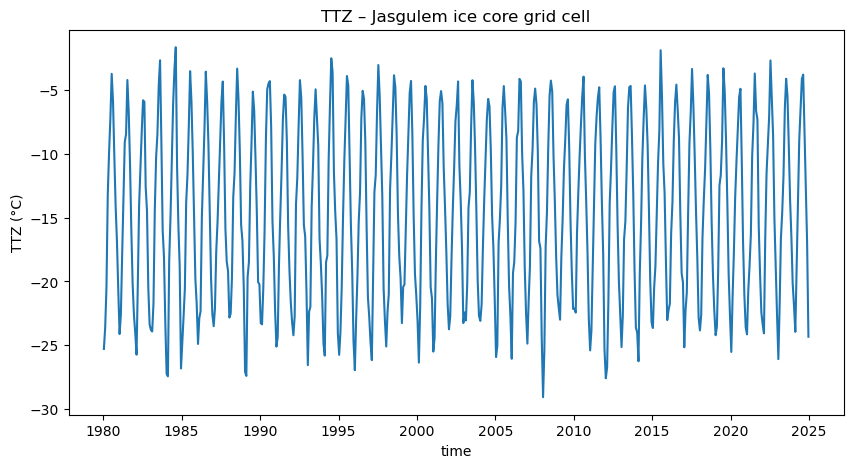

In [23]:
# Uniquement le point de grille de la carotte

print("Indice Y :", iY)
print("Indice X :", iX)

plt.figure(figsize=(10,5))

ds_TTZ.isel(Y=iY, X=iX).plot()

# plt.legend(ncol=3)
plt.title("TTZ – Jasgulem ice core grid cell")
plt.ylabel("TTZ (°C)")
plt.show()

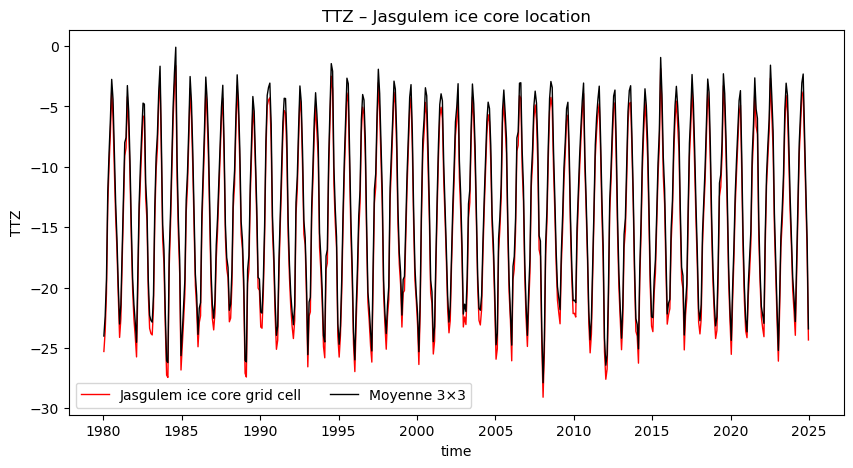

In [24]:
# TTZ at Jasgulem ice core site

plt.figure(figsize=(10,5))

# Plot 9 points individuellement
# for i in range(3):
#     for j in range(3):
#         ds_TTZ.isel(Y=iY-1+i, X=iX-1+j).plot(label=f"Y={iY-1+i}, X={iX-1+j}", alpha=0.5)

ds_TTZ_jasg =  ds_TTZ.isel(Y=iY, X=iX)
ds_TTZ_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="red")

# Moyenne 3×3 grid cells close to drilling site
ds_TTZ_jasg_mean = ds_TTZ.isel(Y=slice(iY-1, iY+2),
                          X=slice(iX-1, iX+2)).mean(dim=["Y", "X"])
ds_TTZ_jasg_mean.plot(label="Moyenne 3×3", linewidth=1, color="black")

plt.legend(ncol=3)
plt.title("TTZ – Jasgulem ice core location")
plt.ylabel("TTZ")
plt.show()

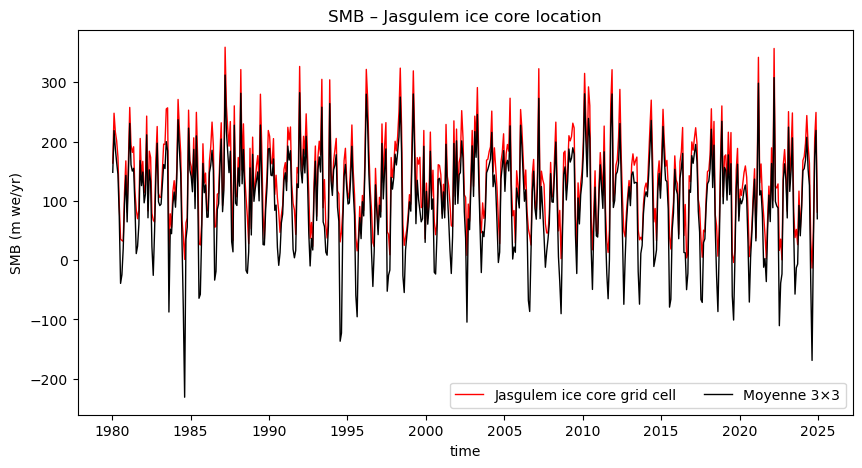

In [25]:
# SMB at Jasgulem ice core site

plt.figure(figsize=(10,5))

# Plot 9 points individuellement
# for i in range(3):
#     for j in range(3):
#         ds_TTZ.isel(Y=iY-1+i, X=iX-1+j).plot(label=f"Y={iY-1+i}, X={iX-1+j}", alpha=0.5)

ds_SMB_jasg =  ds_SMB.isel(Y=iY, X=iX)
ds_SMB_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="red")

# Moyenne 3×3 grid cells close to drilling site
ds_SMB_jasg_mean = ds_SMB.isel(Y=slice(iY-1, iY+2),
                          X=slice(iX-1, iX+2)).mean(dim=["Y", "X"])
ds_SMB_jasg_mean.plot(label="Moyenne 3×3", linewidth=1, color="black")


plt.legend(ncol=3)
plt.title("SMB – Jasgulem ice core location")
plt.ylabel("SMB (m we/yr)")
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(
/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


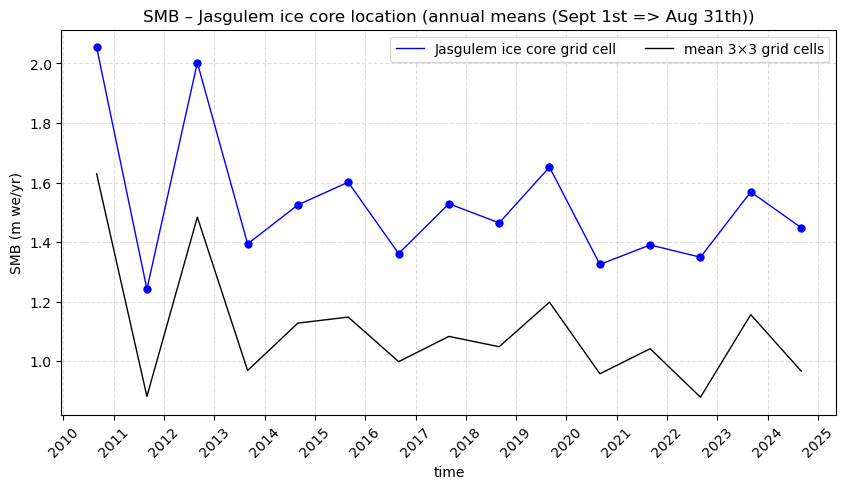

In [34]:
#SMB Annual (from Sept 1 to Aug 31, fpr comparison with ice core record)

plt.figure(figsize=(10,5))

# Point précis Jasgulem
ds_SMB_jasg = ds_SMB.isel(Y=iY, X=iX)
ds_SMB_jasg_annual = ds_SMB_jasg.resample(time="A-AUG").sum().sel(time=slice("2009-09-01", "2024-08-31"))/1000

ds_SMB_jasg_annual.plot(label="Jasgulem ice core grid cell", linewidth=1, color="blue")

plt.plot(ds_SMB_jasg_annual.time,
         ds_SMB_jasg_annual,
         'o', color='blue', markersize=5)

# Moyenne 3×3
ds_SMB_jasg_mean = ds_SMB.isel(Y=slice(iY-1, iY+2),
                               X=slice(iX-1, iX+2)).mean(dim=["Y", "X"])
ds_SMB_jasg_mean_annual = ds_SMB_jasg_mean.resample(time="A-AUG").sum().sel(time=slice("2009-09-01", "2024-08-31"))/1000
ds_SMB_jasg_mean_annual.plot(label="mean 3×3 grid cells", linewidth=1, color="black")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – Jasgulem ice core location (annual means (Sept 1st => Aug 31th))")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

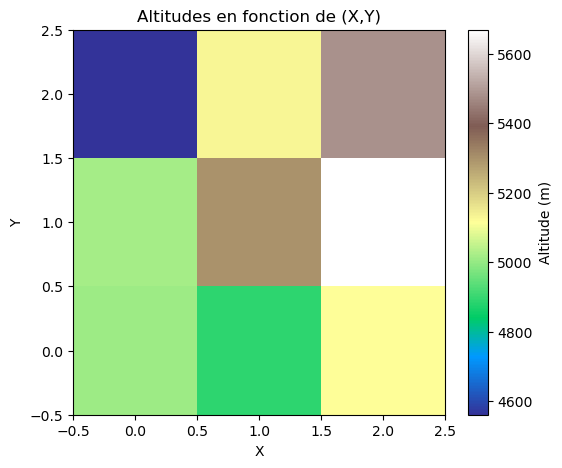

In [28]:
ds_SH_jasg = ds_SH.isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2))
ds_SH_jasg 

X, Y = np.meshgrid([0,1,2], [0,1,2])

plt.figure(figsize=(6,5))
plt.pcolormesh(X, Y, ds_SH_jasg, cmap='terrain', shading='auto')
plt.colorbar(label="Altitude (m)")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Altitudes en fonction de (X,Y)")
plt.show()


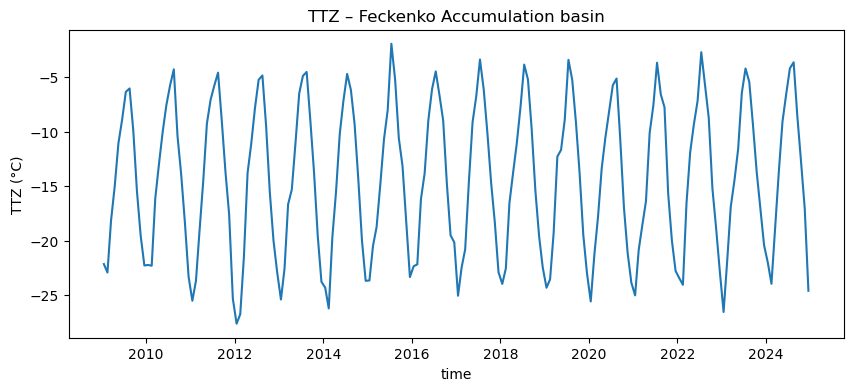

In [29]:
TS_sel = ds_TTZ_Fed.mean(dim=("X", "Y")).sel(time=slice("2009-01-01", "2025-12-31"))

TS_sel.plot(figsize=(10,4))
plt.title("TTZ – Feckenko Accumulation basin")
plt.ylabel("TTZ (°C)")
plt.show()